<a href="https://colab.research.google.com/github/BJut7021/TH_DeepLearning/blob/main/Regression_Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Chuẩn bị dữ liệu và Khởi tạo Mô hình**

In [9]:

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Sequential
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

np.random.seed(42)
n_samples = 1000

dien_tich = np.random.uniform(30, 150, n_samples)
so_phong = np.random.randint(1, 5, n_samples)
khoang_cach = np.random.uniform(1, 20, n_samples)


nhiieu = np.random.normal(0, 250, n_samples)
gia_nha = (dien_tich * 15) + (so_phong * 50) - (khoang_cach * 5) + nhiieu



for i in range(10):
    idx = np.random.randint(0, n_samples)
    gia_nha[idx] += 2000

# Chuyển thành DataFrame
df = pd.DataFrame({
    'DienTich': dien_tich,
    'SoPhong': so_phong,
    'KhoangCach': khoang_cach,
    'GiaNha': gia_nha
})


X = df[['DienTich', 'SoPhong', 'KhoangCach']].values
y = df['GiaNha'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Huấn luyện Mô hình**

In [10]:

history = model.fit(X_train_scaled, y_train,
                    epochs=100,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=1)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 99601.6172 - mae: 211.8807 - val_loss: 82869.5391 - val_mae: 210.0209
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 98666.4844 - mae: 211.1991 - val_loss: 83470.7891 - val_mae: 212.5728
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 99132.1719 - mae: 213.4050 - val_loss: 83522.4453 - val_mae: 212.0851
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 99820.6094 - mae: 211.9641 - val_loss: 83572.5000 - val_mae: 212.2105
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 100510.0547 - mae: 213.9355 - val_loss: 84446.9609 - val_mae: 214.0715
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 100578.9453 - mae: 213.9883 - val_loss: 83063.8125 - val_mae: 211.5452
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 99467.7266 - mae: 210.8891 - val_loss: 82812.5000 - val_mae: 211.0035
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 98813.7812 - mae: 210.4278 - va

**Đánh giá và Trực quan hóa Kết quả**

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


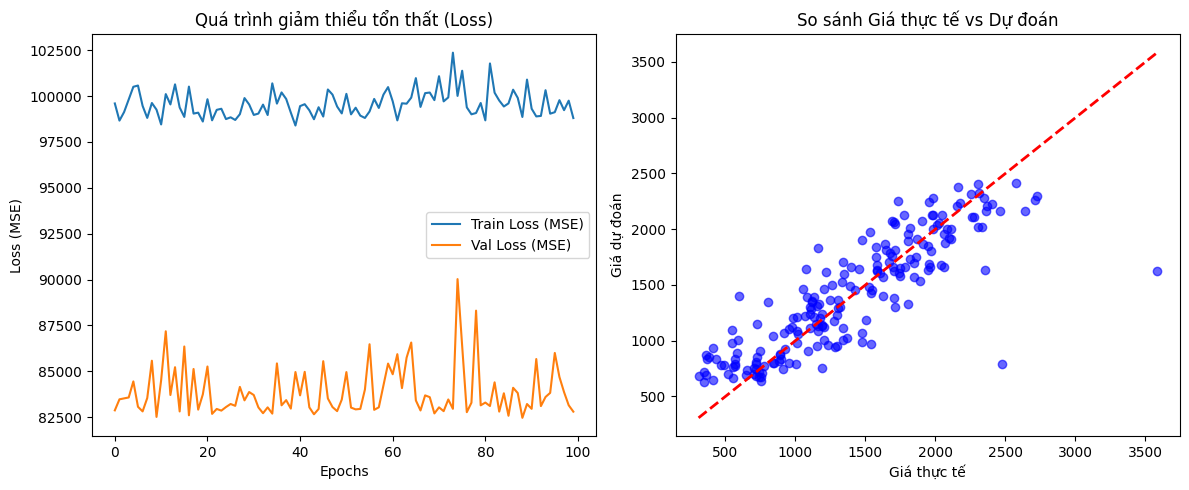

----------------------------------------
Sai số tuyệt đối trung bình (MAE) trên tập Test: 219.77 (triệu đồng)
----------------------------------------


In [11]:

# Vẽ biểu đồ Loss qua các Epochs để kiểm tra Overfitting/Underfitting
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.title('Quá trình giảm thiểu tổn thất (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()

# Dự đoán thử trên tập Test
y_pred = model.predict(X_test_scaled).flatten()

# Vẽ biểu đồ so sánh Giá thực tế vs Giá dự đoán
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, alpha=0.6, color='b')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('So sánh Giá thực tế vs Dự đoán')
plt.xlabel('Giá thực tế')
plt.ylabel('Giá dự đoán')

plt.tight_layout()
plt.show()

# Đánh giá sai số trung bình (MAE) trên tập Test
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(fontfont := "-"*40)
print(f"Sai số tuyệt đối trung bình (MAE) trên tập Test: {test_mae:.2f} (triệu đồng)")
print(fontfont)